<a href="https://colab.research.google.com/github/klm66655/HCI-project/blob/main/Fake_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fake news classifier using long term memory**



In [37]:
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk
from collections import Counter
import string
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize


In [7]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [9]:
# Load the dataset
file_path = 'Fake.csv'  # Replace with the path to your dataset
dataset = pd.read_csv(file_path)

In [10]:
# Display the first few rows of the original dataset
print("Fake News Dataset:")
print(dataset.head())


Fake News Dataset:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [11]:
# Display basic information about the dataset
print("Dataset Overview:")
print(dataset.info())


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None


In [25]:
# Check for unique values in the 'subject' column
unique_subjects = dataset['subject'].unique()
print(f"\nUnique subjects in the dataset: {unique_subjects}")

# Create a new column 'category' based on the 'subject' column
def map_to_category(subject):
    if subject in ['Government News', 'left-news', 'US_News', 'Middle-east', 'News']:
        return 'World News'
    elif subject == 'politics':
        return 'Politics'
    else:
        return 'Other'

dataset['category'] = dataset['subject'].apply(map_to_category)

# Split the dataset into two subsets
world_news = dataset[dataset['category'] == 'World News']
politics_news = dataset[dataset['category'] == 'Politics']

# Save the subsets as separate CSV files
world_news.to_csv('world_news.csv', index=False)
politics_news.to_csv('politics_news.csv', index=False)

# Display the counts of articles in each category
category_counts = Counter(dataset['category'])
print(f"\nCounts of articles by category: {category_counts}")

# Display a preview of each subset
print("\nWorld News preview:")
print(world_news.head())

print("\nPolitics News preview:")
print(politics_news.head())

# Optional: Display top 10 most frequent words in the text column for each subset
stop_words = set(stopwords.words('english'))
def get_top_words(text_series, top_n=10):
    all_words = ' '.join(text_series).lower()
    all_words = ''.join([char for char in all_words if char not in string.punctuation])
    words = all_words.split()
    words = [word for word in words if word not in stop_words]
    return Counter(words).most_common(top_n)

print("\nTop 10 words in World News:")
print(get_top_words(world_news['text']))

print("\nTop 10 words in Politics News:")
print(get_top_words(politics_news['text']))





Unique subjects in the dataset: ['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east']

Counts of articles by category: Counter({'World News': 16640, 'Politics': 6841})

World News preview:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date    category  \
0  December 31, 2017  World News

In [17]:
# Handle missing values by dropping rows with any missing data
dataset = dataset.dropna()

In [18]:
# Display the shape of the dataset after removing missing values
print(f"Dataset shape after dropping missing values: {dataset.shape}")

Dataset shape after dropping missing values: (23481, 5)


**# Text Preprocessing**

In [19]:
stop_words = set(stopwords.words("english"))

In [20]:
# Define the function to clean text
def clean_text(text):
    # Remove non-alphabetic characters and convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text).lower()
    # Remove stop words
    return " ".join([word for word in text.split() if word not in stop_words])

# Apply the cleaning function to the 'text' column
dataset['cleaned_text'] = dataset['text'].apply(clean_text)

# Display the first few rows of the cleaned dataset
print("\nCleaned Dataset:")
print(dataset[['text', 'cleaned_text', 'category']].head())


Cleaned Dataset:
                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

                                        cleaned_text category  
0  donald trump wish americans happy new year lea...    Other  
1  house intelligence committee chairman devin nu...    Other  
2  friday revealed former milwaukee sheriff david...    Other  
3  christmas day donald trump announced would bac...    Other  
4  pope francis used annual christmas day message...    Other  


<ipython-input-26-399dc812dff5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


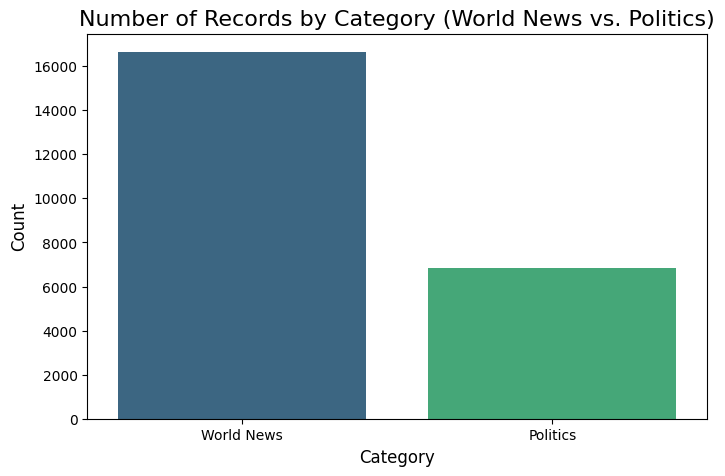

In [26]:
# Count the number of records for each category
category_counts = dataset['category'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Number of Records by Category (World News vs. Politics)", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.show()

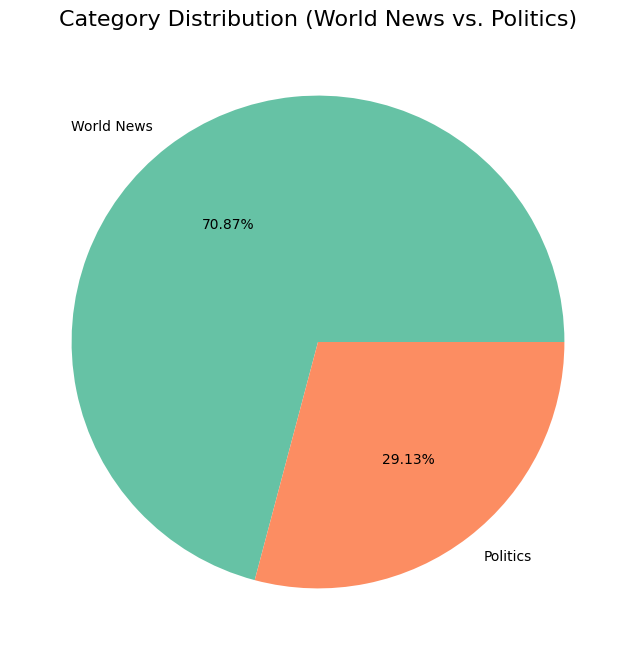

In [27]:
# Count the values in the 'category' column
category_counts = dataset['category'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct="%0.2f%%", colors=['#66c2a5', '#fc8d62'])
plt.title("Category Distribution (World News vs. Politics)", fontsize=16)
plt.show()

**General Info**

In [28]:
# Calculate the number of characters per article and add a new column
dataset['num_characters_per_article'] = dataset['text'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

# Display the first few rows to verify
print("\nDataset with Number of Characters per Article:")
print(dataset[['text', 'num_characters_per_article']].head())



Dataset with Number of Characters per Article:
                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

   num_characters_per_article  
0                        2893  
1                        1898  
2                        3597  
3                        2774  
4                        2346  


In [29]:
dataset.head()

,title,text,subject,date,category,cleaned_text,num_characters_per_article
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",World News,donald trump wish americans happy new year lea...,2893
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",World News,house intelligence committee chairman devin nu...,1898
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",World News,friday revealed former milwaukee sheriff david...,3597
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",World News,christmas day donald trump announced would bac...,2774
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",World News,pope francis used annual christmas day message...,2346


In [36]:
nltk.download('punkt_tab')
# Calculate the number of words per article and add a new column
dataset['num_words'] = dataset['text'].apply(lambda x: len(word_tokenize(str(x))) if pd.notnull(x) else 0)

# Display the first few rows to verify
print("\nDataset with Number of Words per Article:")
print(dataset[['text', 'num_words']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Dataset with Number of Words per Article:
                                                text  num_words
0  Donald Trump just couldn t wish all Americans ...        599
1  House Intelligence Committee Chairman Devin Nu...        331
2  On Friday, it was revealed that former Milwauk...        689
3  On Christmas day, Donald Trump announced that ...        519
4  Pope Francis used his annual Christmas Day mes...        458


In [38]:
# Calculate the number of sentences per article and add a new column
dataset['num_sentences'] = dataset['text'].apply(lambda x: len(sent_tokenize(str(x))) if pd.notnull(x) else 0)

# Display the first few rows to verify
print("\nDataset with Number of Sentences per Article:")
print(dataset[['text', 'num_sentences']].head())


Dataset with Number of Sentences per Article:
                                                text  num_sentences
0  Donald Trump just couldn t wish all Americans ...             28
1  House Intelligence Committee Chairman Devin Nu...             11
2  On Friday, it was revealed that former Milwauk...             25
3  On Christmas day, Donald Trump announced that ...             15
4  Pope Francis used his annual Christmas Day mes...             19


In [40]:
# General statistics for "text".

dataset[['num_characters_per_article','num_words','num_sentences']].describe()

,num_characters_per_article,num_words,num_sentences
count,23481.000000,23481.000000,23481.000000
mean,2547.396235,470.039010,14.919509
std,2532.884399,457.154988,13.792339
min,1.000000,0.000000,0.000000
25%,1433.000000,266.000000,7.000000
50%,2166.000000,403.000000,13.000000
75%,3032.000000,562.000000,19.000000
max,51794.000000,9958.000000,288.000000


In [41]:
# General statistics for "World News"
world_news_stats = dataset[dataset['category'] == 'World News'][['num_characters_per_article', 'num_words', 'num_sentences']].describe()

# Display the statistics
print("\nGeneral Statistics for 'World News':")
print(world_news_stats)



General Statistics for 'World News':
       num_characters_per_article     num_words  num_sentences
count                16640.000000  16640.000000   16640.000000
mean                  2736.378966    505.484615      15.927885
std                   2612.630854    471.206980      13.561841
min                      1.000000      0.000000       0.000000
25%                   1754.000000    327.000000       9.000000
50%                   2293.000000    428.000000      14.000000
75%                   3090.250000    575.000000      20.000000
max                  51794.000000   9958.000000     275.000000


In [42]:
# General statistics for "Politics"
politics_stats = dataset[dataset['category'] == 'Politics'][['num_characters_per_article', 'num_words', 'num_sentences']].describe()

# Display the statistics
print("\nGeneral Statistics for 'Politics':")
print(politics_stats)



General Statistics for 'Politics':
       num_characters_per_article    num_words  num_sentences
count                 6841.000000  6841.000000    6841.000000
mean                  2087.715977   383.821371      12.466745
std                   2262.749298   408.406751      14.039359
min                      1.000000     0.000000       0.000000
25%                    715.000000   133.000000       4.000000
50%                   1655.000000   305.000000       9.000000
75%                   2789.000000   509.000000      16.000000
max                  49705.000000  7826.000000     288.000000


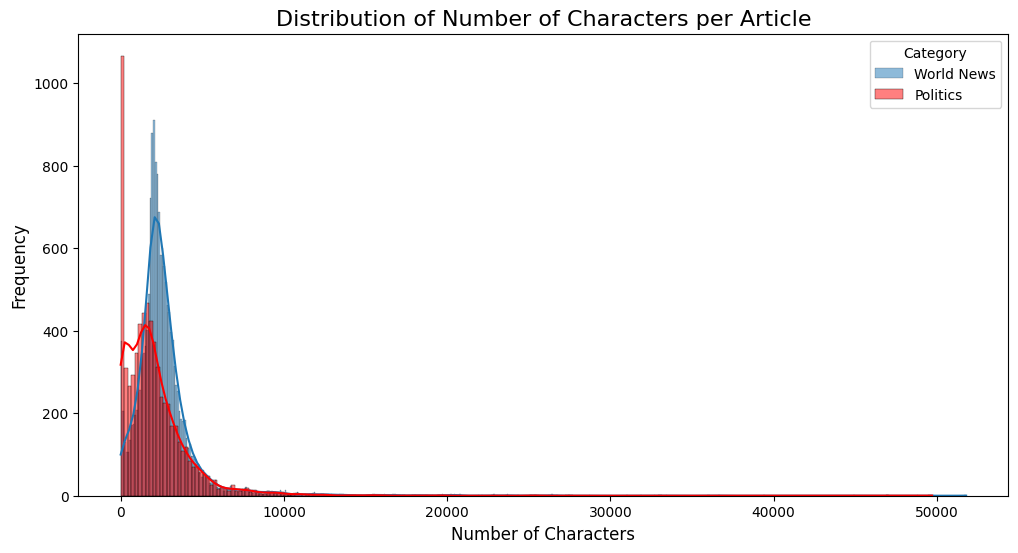

In [43]:
# Plot the distribution of the number of characters per article for World News and Politics
plt.figure(figsize=(12, 6))

# World News distribution
sns.histplot(dataset[dataset['category'] == 'World News']['num_characters_per_article'], label='World News', kde=True)

# Politics distribution
sns.histplot(dataset[dataset['category'] == 'Politics']['num_characters_per_article'], color='red', label='Politics', kde=True)

# Add labels and legend
plt.title("Distribution of Number of Characters per Article", fontsize=16)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Category", fontsize=10)
plt.show()

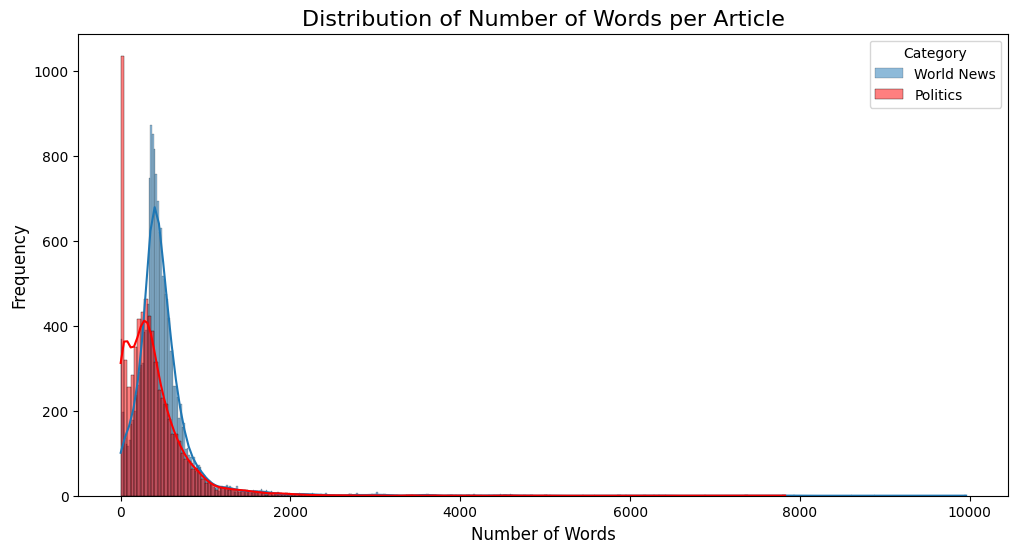

In [44]:
# Plot the distribution of the number of words per article for World News and Politics
plt.figure(figsize=(12, 6))

# World News distribution
sns.histplot(dataset[dataset['category'] == 'World News']['num_words'], label='World News', kde=True)

# Politics distribution
sns.histplot(dataset[dataset['category'] == 'Politics']['num_words'], color='red', label='Politics', kde=True)

# Add labels and legend
plt.title("Distribution of Number of Words per Article", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Category", fontsize=10)
plt.show()


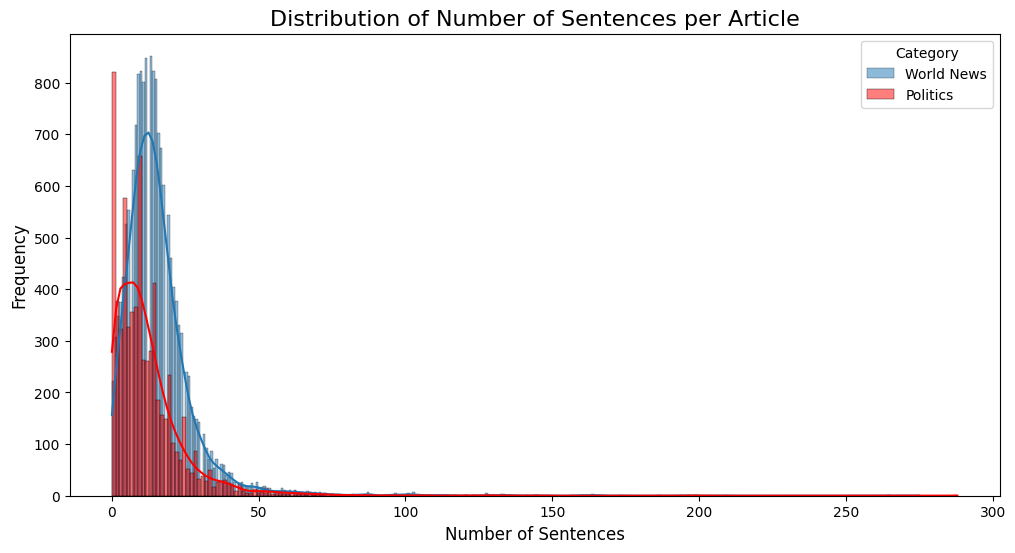

In [45]:
# Plot the distribution of the number of sentences per article for World News and Politics
plt.figure(figsize=(12, 6))

# World News distribution
sns.histplot(dataset[dataset['category'] == 'World News']['num_sentences'], label='World News', kde=True)

# Politics distribution
sns.histplot(dataset[dataset['category'] == 'Politics']['num_sentences'], color='red', label='Politics', kde=True)

# Add labels and legend
plt.title("Distribution of Number of Sentences per Article", fontsize=16)
plt.xlabel("Number of Sentences", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Category", fontsize=10)
plt.show()


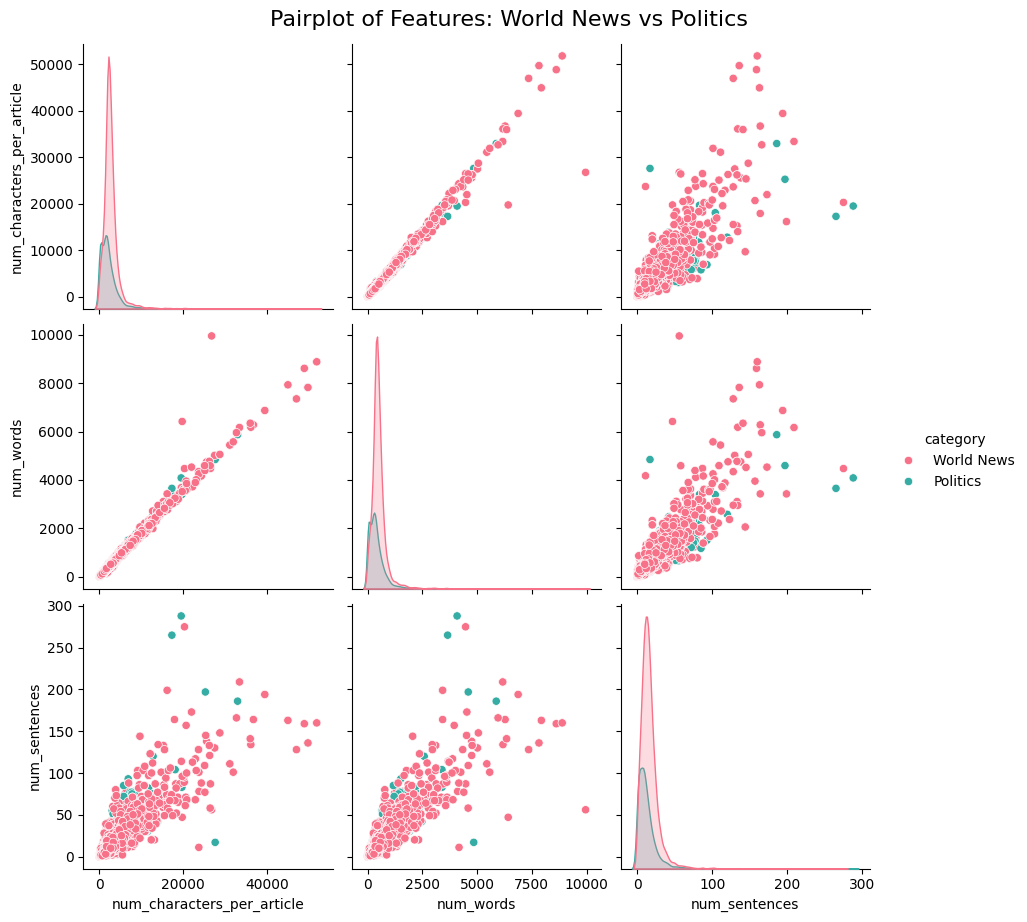

In [47]:
# Pairplot to visualize relationships between features
sns.pairplot(
    dataset,
    hue='category',  # Use 'category' to distinguish between World News and Politics
    vars=['num_characters_per_article', 'num_words', 'num_sentences'],  # Numerical features
    palette='husl',  # Choose a visually appealing palette
    height=3  # Size of each subplot
)

plt.suptitle("Pairplot of Features: World News vs Politics", y=1.02, fontsize=16)
plt.show()


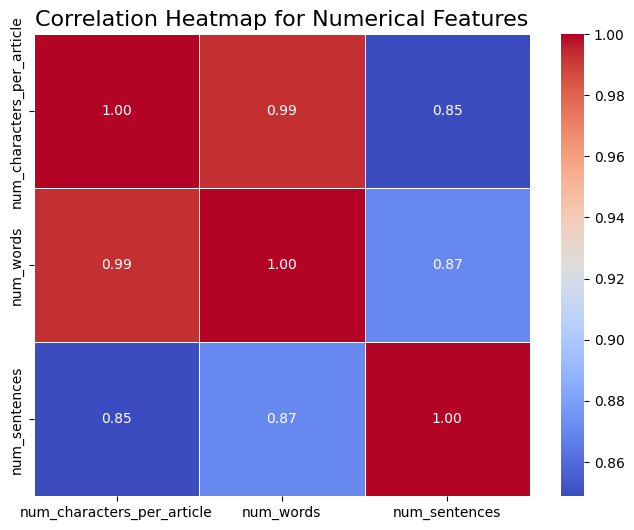

In [48]:
# Select only numerical columns
numeric_columns = dataset.select_dtypes(include=['number'])

# Create the correlation matrix for numerical columns
correlation_matrix = numeric_columns.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Add title and adjust layout
plt.title("Correlation Heatmap for Numerical Features", fontsize=16)
plt.show()


**Cleaning dataset, data preprocessing**




In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   title                       23481 non-null  object
 1   text                        23481 non-null  object
 2   subject                     23481 non-null  object
 3   date                        23481 non-null  object
 4   category                    23481 non-null  object
 5   cleaned_text                23481 non-null  object
 6   num_characters_per_article  23481 non-null  int64 
 7   num_words                   23481 non-null  int64 
 8   num_sentences               23481 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 1.6+ MB


In [50]:
# Importing regular expression for pattern matching - data cleaning.

import re

def cleanTxt(text):
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'\bRT\b', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = re.sub(r'([a-z])\1+', r'\1', text)

    return text

In [51]:
stopwords = set(stopwords.words('english'))

def tokenization_and_cleaning(text):
    word_tokens = nltk.word_tokenize(text)

    # Clean words in sentence
    clean_word_tokens = [cleanTxt(w) for w in word_tokens]

    # Remove stop words, non-alphabetic words
    clean_word_tokens_filtered = [w.lower() for w in clean_word_tokens if w.lower() not in stopwords and w.isalpha()]

    return " ".join(clean_word_tokens_filtered)

In [53]:
# Example of tokenized sentence from dataset:

tokenization_and_cleaning('Breaking: The government is naturally introducing irresistible offers for corporate growth in 2025!')

'breaking government naturaly introducing iresistible ofers corporate growth'

In [55]:
# Add a new column 'text_cleaned' to store the cleaned and tokenized text
dataset['text_cleaned'] = dataset['text'].apply(lambda mail: tokenization_and_cleaning(str(mail)) if pd.notnull(mail) else [])

# Display the first few rows to verify
print("\nDataset with Cleaned Text:")
print(dataset[['text', 'text_cleaned']].head())



Dataset with Cleaned Text:
                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

                                        text_cleaned  
0  donald trump wish al americans hapy new year l...  
1  house inteligence comite chairman devin nunes ...  
2  friday revealed former milwauke sherif david c...  
3  christmas day donald trump anounced would back...  
4  pope francis used anual christmas day mesage r...  
